# ISyE 6525 HW1 - Question 2

For the uniform knot vector

$$
\{\tau_0,\tau_1,\tau_2,\tau_3,\tau_4,\tau_5\}=\{0,1,2,3,4,5\},
$$

the Cox--de Boor recursion is

$$
B_{i,j}(x)=\frac{x-\tau_i}{\tau_{i+j}-\tau_i}B_{i,j-1}(x)
+\frac{\tau_{i+j+1}-x}{\tau_{i+j+1}-\tau_{i+1}}B_{i+1,j-1}(x),
$$

with

$$
B_{i,0}(x)=\begin{cases}1,&i\le x<i+1,\\0,&\text{otherwise}.\end{cases}
$$

## Step 1: degree-one basis functions

Since the knots are one unit apart,

$$
B_{i,1}(x)=(x-i)B_{i,0}(x)+(i+2-x)B_{i+1,0}(x).
$$

The degree-one functions needed below are

$$
B_{0,1}(x)=\begin{cases}
x,&0\le x<1,\\
2-x,&1\le x<2,\\
0,&\text{otherwise},
\end{cases}
\qquad
B_{1,1}(x)=\begin{cases}
x-1,&1\le x<2,\\
3-x,&2\le x<3,\\
0,&\text{otherwise},
\end{cases}
$$

$$
B_{2,1}(x)=\begin{cases}
x-2,&2\le x<3,\\
4-x,&3\le x<4,\\
0,&\text{otherwise},
\end{cases}
\qquad
B_{3,1}(x)=\begin{cases}
x-3,&3\le x<4,\\
5-x,&4\le x<5,\\
0,&\text{otherwise}.
\end{cases}
$$

## Step 2: derive $B_{0,2}(x)$

Using the recursion,

$$
B_{0,2}(x)=\frac{x}{2}B_{0,1}(x)+\frac{3-x}{2}B_{1,1}(x).
$$

Evaluate it on each interval:

$$
B_{0,2}(x)=\begin{cases}
\dfrac{x}{2}(x)=\dfrac{x^2}{2},&0\le x<1,\\[5pt]
\dfrac{x}{2}(2-x)+\dfrac{3-x}{2}(x-1)
=-x^2+3x-\dfrac32,&1\le x<2,\\[5pt]
\dfrac{3-x}{2}(3-x)=\dfrac{(3-x)^2}{2},&2\le x<3,\\[5pt]
0,&\text{otherwise}.
\end{cases}
$$

## Step 3: derive $B_{1,2}(x)$ and $B_{2,2}(x)$

For $B_{1,2}$,

$$
B_{1,2}(x)=\frac{x-1}{2}B_{1,1}(x)+\frac{4-x}{2}B_{2,1}(x),
$$

so

$$
B_{1,2}(x)=\begin{cases}
\dfrac{(x-1)^2}{2},&1\le x<2,\\[5pt]
-(x-1)^2+3(x-1)-\dfrac32,&2\le x<3,\\[5pt]
\dfrac{(4-x)^2}{2},&3\le x<4,\\[5pt]
0,&\text{otherwise}.
\end{cases}
$$

Similarly,

$$
B_{2,2}(x)=\frac{x-2}{2}B_{2,1}(x)+\frac{5-x}{2}B_{3,1}(x),
$$

which gives

$$
B_{2,2}(x)=\begin{cases}
\dfrac{(x-2)^2}{2},&2\le x<3,\\[5pt]
-(x-2)^2+3(x-2)-\dfrac32,&3\le x<4,\\[5pt]
\dfrac{(5-x)^2}{2},&4\le x<5,\\[5pt]
0,&\text{otherwise}.
\end{cases}
$$

Because the knots are uniform, these are translated copies:

$$
B_{1,2}(x)=B_{0,2}(x-1),\qquad B_{2,2}(x)=B_{0,2}(x-2).
$$

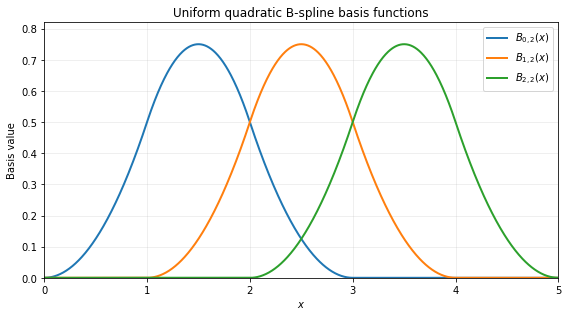

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def B02(x):
    x = np.asarray(x, dtype=float)
    return np.select(
        [(0 <= x) & (x < 1),
         (1 <= x) & (x < 2),
         (2 <= x) & (x < 3)],
        [x**2 / 2,
         -x**2 + 3*x - 3/2,
         (3-x)**2 / 2],
        default=0.0,
    )

def B12(x):
    return B02(np.asarray(x) - 1)

def B22(x):
    return B02(np.asarray(x) - 2)

x = np.linspace(0, 5, 1001)

plt.figure(figsize=(8, 4.5))
plt.plot(x, B02(x), label=r'$B_{0,2}(x)$', linewidth=2)
plt.plot(x, B12(x), label=r'$B_{1,2}(x)$', linewidth=2)
plt.plot(x, B22(x), label=r'$B_{2,2}(x)$', linewidth=2)
plt.xticks(range(6))
plt.xlim(0, 5)
plt.ylim(0, 0.82)
plt.xlabel('$x$')
plt.ylabel('Basis value')
plt.title('Uniform quadratic B-spline basis functions')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()